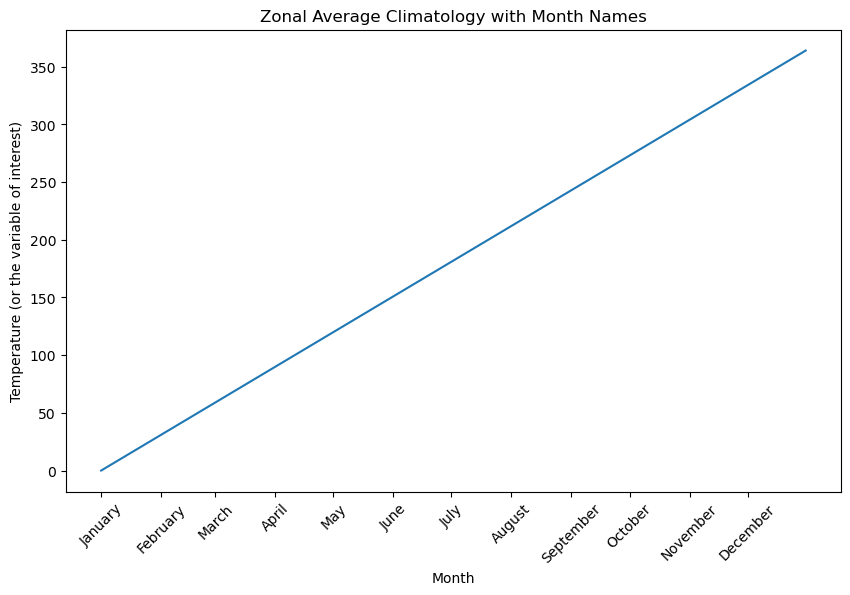

In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# Sample DataArray with a time dimension
time = pd.date_range('2021-01-01', periods=365, freq='D')  # Daily data for one year
data = xr.DataArray(range(365), coords=[time], dims='time')

# Calculate climatology (for demonstration, we use the same data)
data['time'] = pd.to_datetime(data['time'].values)
doy_grouped = data.groupby('time.dayofyear')
doy_climatology = doy_grouped.mean(dim='time')

# Create the plot
plt.figure(figsize=(10, 6))
doy_climatology.plot()

# Get the positions of the start of each month
months = pd.date_range('2021-01-01', periods=12, freq='MS')
month_starts = months.dayofyear

# Get the month names
month_names = months.strftime('%B')

# Set the x-ticks to the start of each month
plt.xticks(month_starts, month_names, rotation=45)

plt.title('Zonal Average Climatology with Month Names')
plt.xlabel('Month')
plt.ylabel('Temperature (or the variable of interest)')
plt.show()
